In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


In [ ]:
import os
df = os.path.join(path,'train')

In [ ]:
#Loading the Training Dataset using keras.utils.image_dataset
from tensorflow import keras
train_ds = keras.utils.image_dataset_from_directory(
    directory=os.path.join(path, 'train'),
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
)

#Loading the validation dataset using keras.utils.image_dataset
validation_ds = keras.utils.image_dataset_from_directory(
    directory=os.path.join(path, 'test'),
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [ ]:
#Normalize
#0-255 -> 0-1
import tensorflow as tf
def process(image, label):
  image = tf.cast(image/255, tf.float32)
  return image, label
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
#CNN Model
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import Sequential
model = Sequential()

#1st convolution Block
model.add(Conv2D(32, kernel_size=(3,3), activation='relu', padding='valid'))
model.add(MaxPooling2D(pool_size=(2,2)))
#2nd convolution Block
model.add(Conv2D(64, kernel_size=(3,3), activation='relu', padding='valid'))
model.add(MaxPooling2D(pool_size=(2,2)))
#3rd convolution Block
model.add(Conv2D(128, kernel_size=(3,3), activation='relu', padding='valid'))
model.add(MaxPooling2D(pool_size=(2,2)))

#Flattering Layer
model.add(Flatten())

#Fully connected layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(1, activation='sigmoid'))



In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(train_ds, epochs=10, validation_data = validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 104ms/step - accuracy: 0.5932 - loss: 0.6646 - val_accuracy: 0.6948 - val_loss: 0.5839
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.7440 - loss: 0.5210 - val_accuracy: 0.7344 - val_loss: 0.5402
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.8117 - loss: 0.4127 - val_accuracy: 0.7782 - val_loss: 0.4972
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.8777 - loss: 0.2816 - val_accuracy: 0.7440 - val_loss: 0.7102
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.9354 - loss: 0.1647 - val_accuracy: 0.7542 - val_loss: 0.9030
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 76ms/step - accuracy: 0.9625 - loss: 0.1039 - val_accuracy: 0.7486 - val_loss: 1.0100
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 77ms/step - accuracy: 0.9747 - loss: 0.0735 - val_accuracy: 0.7528 - val_loss: 1.1692
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.9821 - loss: 0.0538 -

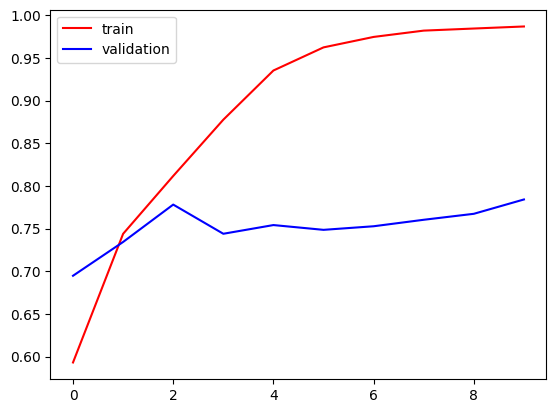

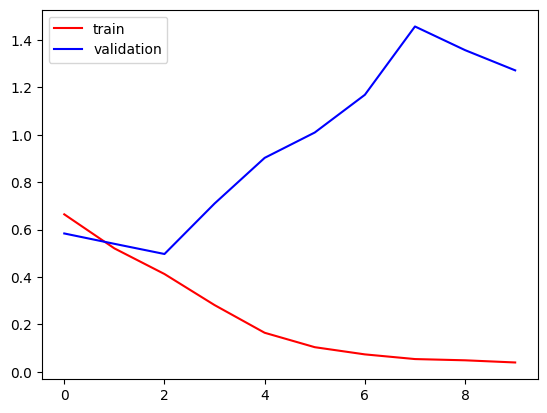

In [ ]:
import matplotlib.pyplot as plt

# Retrieve the history from your model
history = _  # In Colab, _ usually holds the output of the last cell (the History object)

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()

In [ ]:
# Evaluate the model on the validation dataset
loss, accuracy = model.evaluate(validation_ds)
print(f"Final Test Accuracy: {accuracy*100:.2f}%")

157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.7842 - loss: 1.2723
Final Test Accuracy: 78.42%


In [ ]:
model.save('cat_dog_model.keras')
print("Model saved as cat_dog_model.keras")

Model saved as cat_dog_model.keras
